# Multi-Class Jet Tagging with NNs

In this tutorial, we move from a simple binary classification problem to a more realistic multi-class physics task: identifying jets produced at the LHC with a neural network.

Just like in the first tutorial, we will train, evaluate, and compare models step by step, but this time the problem is more challenging. Instead of predicting only two classes, our model must distinguish between five jet types using high-level physics features.

We use the hls4ml LHC jet dataset from OpenML. \
It contains about 830,000 jet events, 16 high-level input features, and 5 jet classes:
- quark (q),
- gluon (g),
- W boson (w),
- Z boson (z),
- top quark (t).

In this tutorial, we will focus on:

- Multi-class neural network training and evaluation

- Class prediction probabilities and confusion between jet classes

- ROC/AUC-style performance comparisons for multi-class classification


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/Multi-Class_Classification_NN.ipynb)

# 1. Import Libraries

In [110]:
import numpy as np
import tensorflow as tf
import pandas as pd

from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
RANDOM_STATE = 42

## 2. Load and Inspect the Dataset


In [111]:
data = fetch_openml('hls4ml_lhc_jets_hlf')
X, y = data['data'], data['target']

print("Feature names:")
print(list(data["feature_names"]))

print("\nInput shape and target shape:")
print("X:", X.shape)
print("y:", y.shape)

print("\nFirst 5 input rows:")
display(X.head())

print("\nFirst 5 labels:")
display(y.head())

print("\nClass names:")
print(y.cat.categories.tolist())

Feature names:
['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']

Input shape and target shape:
X: (830000, 16)
y: (830000,)

First 5 input rows:


,zlogz,c1_b0_mmdt,c1_b1_mmdt,c1_b2_mmdt,c2_b1_mmdt,c2_b2_mmdt,d2_b1_mmdt,d2_b2_mmdt,d2_a1_b1_mmdt,d2_a1_b2_mmdt,m2_b1_mmdt,m2_b2_mmdt,n2_b1_mmdt,n2_b2_mmdt,mass_mmdt,multiplicity
0,-2.935125,0.383155,0.005126,0.000084,0.009070,0.000179,1.769445,2.123898,1.769445,0.308185,0.135687,0.083278,0.412136,0.299058,8.926882,75.0
1,-1.927335,0.270699,0.001585,0.000011,0.003232,0.000029,2.038834,2.563099,2.038834,0.211886,0.063729,0.036310,0.310217,0.226661,3.886512,31.0
2,-3.112147,0.458171,0.097914,0.028588,0.124278,0.038487,1.269254,1.346238,1.269254,0.246488,0.115636,0.079094,0.357559,0.289220,162.144669,61.0
3,-2.666515,0.437068,0.049122,0.007978,0.047477,0.004802,0.966505,0.601864,0.966505,0.160756,0.082196,0.033311,0.238871,0.094516,91.258934,39.0
4,-2.484843,0.428981,0.041786,0.006110,0.023066,0.001123,0.552002,0.183821,0.552002,0.084338,0.048006,0.014450,0.141906,0.036665,79.725777,35.0



First 5 labels:


,class
0,g
1,w
2,t
3,z
4,w



Class names:
['g', 'q', 't', 'w', 'z']


## Feature explanation

| Feature       | Meaning                                                                                                                       |
| ------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| zlogz         | A jet substructure variable related to how momentum is distributed among particles inside the jet.              |
| c1_b0_mmdt    | Energy correlation feature C1 with parameter setting β=0,  mainly sensitive to the overall radiation pattern of the jet.          |
| c1_b1_mmdt    | Energy correlation feature C1 with β=1. |
| c1_b2_mmdt    | Energy correlation feature C1 with β=2. |
| c2_b1_mmdt    | Energy correlation feature C2 with β=1, used to describe jet shape and prong structure.          |
| c2_b2_mmdt    | Energy correlation feature C2 with β=2.        |
| d2_b1_mmdt    | Energy correlation feature D2 with β=1, used to distinguish one-prong jets from two-prong or more complex jets.|
| d2_b2_mmdt    | Energy correlation feature D2 with β=2.  |
| d2_a1_b1_mmdt | Variant of the D2 observable with additional parameter choices. |
| d2_a1_b2_mmdt | Another variant of the D2 observable with different parameter settings.                 |
| m2_b1_mmdt    | Energy correlation feature M2 with β=1, used to describe finer details of jet substructure.   |
| m2_b2_mmdt    | Energy correlation feature M2 with β=2. |
| n2_b1_mmdt    | Energy correlation feature N2 with β=1, sensitive to the internal prong structure of a jet.      |
| n2_b2_mmdt    | Energy correlation feature N2 with β=2.                 |
| mass_mmdt     | Groomed jet mass after the modified mass-drop tagger (mMDT) procedure.                 |
| multiplicity  | Number of constituents or particles reconstructed inside the jet.       |
| target        | Jet class label: g = gluon, q = quark, t = top quark, w = W boson, z = Z boson.                       |

\
β controls how strongly the observable depends on the angular separation of particles inside the jet:

smaller β is less angle-sensitive, while larger β emphasizes the jet’s geometric structure more strongly.

## 3. Encode Labels and Split Dataset

As you saw above, the `y` target is an array of strings, e.g. \['g', 'w',...\] etc.  
We map them to integers and split the dataset into training and validation sets:

- 70% training
- 15% validation
- 15% test

with equal representation of classes by using stratify.

In [112]:
# @title
import ipywidgets as widgets
from IPython.display import display, Markdown
import re

display(Markdown("### Question 1"))
display(Markdown("What is the purpose of the various datasets?"))

answer = widgets.Textarea(
    placeholder="Write your answer here...",
    layout=widgets.Layout(width="700px", height="140px")
)

button = widgets.Button(description="Check answer", button_style="info")
output = widgets.Output()

def contains_any(text, keywords):
    return any(k in text for k in keywords)

def check_answer(b):
    user = answer.value.strip().lower()
    user = re.sub(r"\s+", " ", user)

    train_ok = (
        contains_any(user, ["train", "training"]) and
        contains_any(user, ["fit", "fitting", "train the model", "learn", "training the model", "trains the model", "teach the model"]) and
        contains_any(user, ["weights", "parameters", "model parameters", "train the model", "training the model", "trains the model"])
    )

    val_ok = (
        contains_any(user, ["val", "validation"]) and
        contains_any(user, ["hyperparameter", "hyperparameters", "performance", "model parameters", "the model"]) and
        contains_any(user, ["learn", "tune", "tuning", "improve", "improving", "monitor", "adjust", "adjusting"]) and
        contains_any(user, ["performance", "overfit", "development", "without influencing the training", "early-stopping", "early stopping", "select the model", "choose the model", "best model", "model selection", "overfitting", "tune the model"])
    )

    test_ok = (
        contains_any(user, ["test", "testing"]) and
        contains_any(user, ["final", "finalized", "at the end", "last", "never seen", "new data", "unseen", "held-out", "not used in training", "only", "solely", "unbiased", "separate"]) and
        contains_any(user, ["measure", "measures", "reporting", "report", "testing", "compare", "comparing", "comparison", "check", "checking", "test", "evaluation", "evaluating", "evaluate"])
    )

    with output:
        output.clear_output()
        if train_ok and val_ok and test_ok:
            print("Correct!")
            print("Train: used to fit model parameters (weights/trees).")
            print("Validation: used to tune hyperparameters and for early stopping / model selection.")
            print("Test: used once at the end for final reporting and comparison.")
        else:
            print("Not quite yet.")
            print("Make sure you describe each dataset separately and explain its role clearly.")

button.on_click(check_answer)

display(answer, button, output)


### Question 1

What is the purpose of the various datasets?

Textarea(value='', layout=Layout(height='140px', width='700px'), placeholder='Write your answer here...')

Button(button_style='info', description='Check answer', style=ButtonStyle())

Output()

In [113]:
# Convert y strings into integers
class_names = ['g', 'q', 'w', 'z', 't']
codecs = {name: i for i, name in enumerate(class_names)}
y = np.array([codecs[label] for label in y])

# Split data in train vs val_test
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

# Split val_test in half
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_val_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (581000, 16)
Validation shape: (124500, 16)
Test shape: (124500, 16)


## 4. Feature Scaling

Neural networks train better when input features are scaled / standardized.

We:
- Fit the scaler on training data only
- Apply the same transformation to validation and test sets

In [114]:
# Convert to float32
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

# Scale using training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [115]:
# @title
import ipywidgets as widgets
from IPython.display import display, Markdown
import re

display(Markdown("### Question 2"))
display(Markdown("Why do neural networks train better when input features are standardized?"))

answer = widgets.Textarea(
    placeholder="Write your answer here...",
    layout=widgets.Layout(width="700px", height="140px")
)

button = widgets.Button(description="Check answer", button_style="info")
output = widgets.Output()

def contains_any(text, keywords):
    return any(k in text for k in keywords)

def check_answer(b):
    user = answer.value.strip().lower()
    user = re.sub(r"\s+", " ", user)

    scale_ok = contains_any(user, [
        "same scale", "comparable scale", "similar scale", "same scales", "comparable scales", "similar scales","standardized",
        "zero mean", "unit variance", "normalized", "center around zero", "centers around zero", "similar range", "similar ranges", "symmetric"
    ])

    train_ok = contains_any(user, [
        "train faster", "faster training", "more stable", "stable training", "stabilize",
        "converge better", "better convergence", "optimization", "optimizer", "stabilizes",
        "gradient descent", "gradients", "converge faster", "more reliably", "more reliable", "gradient-based",
        "balanced", "more efficient", "more efficiently"
    ])

    dominate_ok = contains_any(user, [
        "no feature dominates", "prevent one feature from dominating",
        "large-magnitude feature dominates", "large feature dominates", "large value features dominate", "large value feature dominates",
        "balanced gradients", "features contribute more equally",
        "one input can dominate", "dominate the gradients", "equal contribution", "prevents features with large values from dominating", "prevent features with large values from dominating"
    ])

    with output:
        output.clear_output()
        if scale_ok and train_ok and dominate_ok:
            print("Correct!")
            print("Standardization helps neural networks train faster and more stably")
            print("because gradient-based optimizers work better when input features")
            print("are on a comparable scale, so no large-magnitude feature dominates the gradients.")
        else:
            print("Not quite yet.")
            if not scale_ok:
                print("- Hint: mention comparable feature scales")

            if not train_ok:
                print("- Hint: explain how standardization helps gradient-based training")

            if not dominate_ok:
                print("- Hint: mention why large-magnitude features can cause problems")

button.on_click(check_answer)

display(answer, button, output)

### Question 2

Why do neural networks train better when input features are standardized?

Textarea(value='', layout=Layout(height='140px', width='700px'), placeholder='Write your answer here...')

Button(button_style='info', description='Check answer', style=ButtonStyle())

Output()

In [116]:
# @title
import ipywidgets as widgets
from IPython.display import display, Markdown
import re

display(Markdown("### Question 3"))
display(Markdown("Why do we fit the scaler on training data only?"))

answer = widgets.Textarea(
    placeholder="Write your answer here...",
    layout=widgets.Layout(width="700px", height="140px")
)

button = widgets.Button(description="Check answer", button_style="info")
output = widgets.Output()

def contains_any(text, keywords):
    return any(k in text for k in keywords)

def check_answer(b):
    user = answer.value.strip().lower()
    user = re.sub(r"\s+", " ", user)

    prevent_ok = contains_any(user, [
        "prevent", "avoid", "reduce", "limit", "minimize", "stop", "block", "protect against", "keep from", "only the training data", "only from the data the model is allowed to", "only data the model should"
    ])

    leak_ok = contains_any(user, [
        "leakage", "leak", "mixing", "leaking", "adding", "combining", "mix", "combine", "add", "computed only", "gain", "influence", "biases", "biased", "bias"
    ])

    data_ok = (
        contains_any(user, [
            "data", "mean and std", "mean/std", "datasets", "dataset",
            "statistics", "info", "information", "parameters", "mean and standard deviation"
        ])
    )

    valtest_ok = contains_any(user, [
        "validation", "test", "val/test", "validation/test", "unseen data", "other data", "val or test"
    ])

    fairness_ok = contains_any(user, [
        "fair", "honest", "unbiased", "good", "reliable", "trustworthy", "best", "correctly",
        "realistic", "proper", "final", "preprocessing", "true", "real", "correct", "unbiased"
    ])

    evaluation_ok = contains_any(user, [
        "evaluated", "process", "evaluation", "preprocessing", "check", "test", "checking", "testing", "evaluating", "evaluate", "preprocess", "pre-process", "performance"
    ])

    with output:
        output.clear_output()
        if prevent_ok and leak_ok and data_ok and valtest_ok and fairness_ok and evaluation_ok:
            print("Correct!")
            print("We fit the scaler on the training data only to avoid data leakage.")
            print("If we learn the mean/std from validation or test data,")
            print("information from those sets leaks into preprocessing,")
            print("which makes the final evaluation less fair and less realistic.")
        else:
            print("Not quite yet.")

            if not prevent_ok or not leak_ok or not data_ok:
                print("- Hint: mention why we should prevent data leakage.")

            if not valtest_ok:
                print("- Hint: mention validation and/or test data explicitly.")

            if not fairness_ok or not evaluation_ok:
                print("- Hint: explain why this matters for a fair or realistic final evaluation.")

button.on_click(check_answer)

display(answer, button, output)

### Question 3

Why do we fit the scaler on training data only?

Textarea(value='', layout=Layout(height='140px', width='700px'), placeholder='Write your answer here...')

Button(button_style='info', description='Check answer', style=ButtonStyle())

Output()

In case the automatic download does not work, a local backup of the dataset that can be loaded instead:

In [117]:
!rm -rf /content/Scies4Free-FastML-tutorial
!git clone https://github.com/nairods/Scies4Free-FastML-tutorial.git
# DATA_PATH = "Scies4Free-FastML-tutorial/data/jet_tagging/"

# train = np.load(DATA_PATH + "train.npz", allow_pickle=True)
# val   = np.load(DATA_PATH + "val.npz", allow_pickle=True)
# test  = np.load(DATA_PATH + "test.npz", allow_pickle=True)

feature_names = ['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']
# print("Feature names:")
# print(feature_names)

# X_train, y_train = train["X"], train["y"]
# X_val,   y_val   = val["X"],   val["y"]
# X_test,  y_test  = test["X"],  test["y"]

Cloning into 'Scies4Free-FastML-tutorial'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 359 (delta 71), reused 1 (delta 1), pack-reused 236 (from 1)
Receiving objects: 100% (359/359), 96.47 MiB | 34.46 MiB/s, done.
Resolving deltas: 100% (175/175), done.


We need to convert the class labels into one-hot vectors so that they match the softmax output of the network  
and can be properly compared using categorical cross-entropy loss.

One-hot encoding represents each class as a vector with a 1 at the correct class position and 0 elsewhere:
- class 0 -> (1,0,0,0,0)
- class 1 -> (0,1,0,0,0)
- class 2 -> (0,0,1,0,0)
- class 3 -> (0,0,0,1,0)
- class 4 -> (0,0,0,0,1)

In [118]:
# Convert Labels to One-Hot representation
y_train = to_categorical(y_train, 5)
y_val = to_categorical(y_val, 5)
y_test = to_categorical(y_test, 5)

## 5. Build the Neural Network

This task is more challenging than the earlier heart disease example, not only because it has five classes instead of two, but also because the input features are more complex and the classes are less cleanly separated. Some jet types share similar patterns, and the correlations between features make the classification problem harder.

To handle this added complexity, we use a slightly larger neural network architecture:

- Three hidden layers with 64, 32, and 32 neurons.

- A ReLU activation after each hidden layer.

- Five output neurons, one for each jet class.

- A final Softmax activation to produce class probabilities for multi-class classification.

In [119]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
import sys
repo_path = "/content/Scies4Free-FastML-tutorial"
sys.path.insert(0, repo_path)
from callbacks import all_callbacks

We initialize the weights with lecun_uniform, which provides the network with a sensible random starting point before training. This helps break symmetry, so different neurons can learn different features instead of all behaving in the same way.

In the first part of the tutorial, we used L2 regularization. Here, we switch to L1 regularization because it encourages the network to suppress less important connections by pushing some weights toward zero, which will be useful later when we discuss the FastML implementation. By contrast, L2 regularization mainly keeps weights small and smooths the model, but it does not usually drive weights exactly to zero.

A simple way to think about the difference is:

- L1 promotes sparsity, so more weights become zero or very close to zero.

- L2 promotes smallness, so weights remain spread out but with smaller values overall.

In [120]:
model = Sequential()
model.add(Dense(64, input_shape=(X_train.shape[1],), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [121]:
# @title
import ipywidgets as widgets
from IPython.display import display, Markdown
import re


display(Markdown("### Question 4"))
display(Markdown("Why do we use regularization?"))


answer = widgets.Textarea(
    placeholder="Write your answer here...",
    layout=widgets.Layout(width="700px", height="140px")
)


button = widgets.Button(description="Check answer", button_style="info")
output = widgets.Output()


def contains_any(text, keywords):
    return any(k in text for k in keywords)


def check_answer(b):
    user = answer.value.strip().lower()
    user = re.sub(r"\s+", " ", user)


    overfit_ok = contains_any(user, [
        "overfitting", "overfit", "overfits", "fit noise", "memorize", "memorise",
        "memorizing", "memorising", "training data too closely", "noise"
    ])

    generalization_ok = contains_any(user, [
        "generalization", "generalisation", "generalize", "generalise", "stabilizes training", "stabilization",
        "unseen data", "new data", "test data", "validation data", "generalises", "stable training",
        "better performance on unseen data", "improve generalization", "generalizes", "stabilisation"
    ])


    with output:
        output.clear_output()
        if overfit_ok and generalization_ok:
            print("Correct!")
            print("Regularization helps reduce overfitting.")
            print("It discourages overly large weights or overly complex models,")
            print("so the model generalizes better to unseen data.")
        else:
            print("Not quite yet.")

            if not overfit_ok and not generalization_ok:
                print("- Hint: Think about why smaller weights or less complex models can be helpful.")

            elif not overfit_ok:
                print("- Hint: What training problem are we trying to avoid when the model learns the training data too closely?")

            elif not generalization_ok:
                print("- Hint: Why do we want to reduce overfitting? Think about performance beyond the training set.")


button.on_click(check_answer)


display(answer, button, output)

### Question 4

Why do we use regularization?

Textarea(value='', layout=Layout(height='140px', width='700px'), placeholder='Write your answer here...')

Button(button_style='info', description='Check answer', style=ButtonStyle())

Output()

## 6. Train the model

We train the neural network using the Adam optimizer and categorical cross-entropy loss. During training, the learning rate is automatically reduced if the monitored validation metric stops improving, and the best-performing model is saved in the `jet_models` directory.

The network is still relatively small, so training should finish within a few minutes even on a CPU. If you have already trained the model and restarted the notebook kernel, you can set `train = False` to skip training and load the saved model instead.

In [122]:
train = True
if train:
    adam = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=adam,
        loss=['categorical_crossentropy'],
        metrics=['accuracy']
    )

    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='jet_models',
        model_tag='mlp'
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=1024,
        epochs=20,
        shuffle=True,
        callbacks=callbacks.callbacks,
        verbose=1
    )
else:
    from tensorflow.keras.models import load_model
    model = load_model('jet_models/mlp_best.keras')

Epoch 1/20
566/568 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3874 - loss: 1.4899
***callbacks***
saving losses to jet_models/mlp_losses.log

Epoch 1: val_loss improved from None to 1.10075, saving model to jet_models/mlp_best.keras

Epoch 1: finished saving model to jet_models/mlp_best.keras

Epoch 1: val_loss improved from None to 1.10075, saving model to jet_models/mlp_best.weights.h5

Epoch 1: finished saving model to jet_models/mlp_best.weights.h5

Epoch 1: saving model to jet_models/mlp_last.keras

Epoch 1: finished saving model to jet_models/mlp_last.keras

Epoch 1: saving model to jet_models/mlp_last.weights.h5

Epoch 1: finished saving model to jet_models/mlp_last.weights.h5

Epoch 1: saving model to jet_models/mlp_epoch01.keras

Epoch 1: finished saving model to jet_models/mlp_epoch01.keras

***callbacks end***

568/568 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5166 - loss: 1.3132 - val_accuracy: 0.6365 - val_loss: 1.1007 - learning_rate: 1.0000e-04
Epoch 2/20
566/56

### Training History

We plot train vs validation curves for loss and accuracy.

In [123]:
# @title
import ipywidgets as widgets
from IPython.display import display, Markdown
import re


display(Markdown("### Question 5"))
display(Markdown("How can you recognize overtraining from the training history?"))


answer = widgets.Textarea(
    placeholder="Write your answer here...",
    layout=widgets.Layout(width="700px", height="140px")
)


button = widgets.Button(description="Check answer", button_style="info")
output = widgets.Output()


def contains_any(text, keywords):
    return any(k in text for k in keywords)


def check_answer(b):
    user = answer.value.strip().lower()
    user = re.sub(r"\s+", " ", user)


    train_ok = contains_any(user, [
        "training", "train"
    ])


    val_ok = contains_any(user, [
        "validation", "val"
    ])


    train_trend_ok = contains_any(user, [
        "training keeps improving", "train keeps improving",
        "training improves", "train improves",
        "training loss decreases", "train loss decreases",
        "training loss falls", "train loss falls",
        "training loss lowers", "train loss lowers",
        "training loss gets lower", "train loss gets lower",
        "training accuracy increases", "train accuracy increases",
        "training accuracy rises", "train accuracy rises",
        "training accuracy gets higher", "train accuracy gets higher",
        "training gets better", "train gets better",
        "training continues improving", "train continues improving",
        "training continues to improve", "train continues to improve",
        "training continues to get better", "train continues to get better",
        "training loss continues improving", "train loss continues improving",
        "training loss continues to improve", "train loss continues to improve",
        "training loss continues to get better", "train loss continues to get better",
        "training loss continues to decrease", "train loss continues to decrease",
        "training accuracy continues improving", "train accuracy continues improving",
        "training accuracy continues to improve", "train accuracy continues to improve",
        "training accuracy continues to get better", "train accuracy continues to get better",
        "keeps improving on the training data", "improves on the training data",
        "gets better on the training data", "continues improving on the training data",
        "training loss steadily decreases", "train loss steadily decreases",
        "training accuracy steadily increases", "train accuracy steadily increases",
        "well on the training", "well on training", "well on train", "well on the train"
    ])

    val_trend_ok = contains_any(user, [
        "validation stops improving", "val stops improving",
        "validation worsens", "val worsens",
        "validation gets worse", "val gets worse",
        "validation loss increases", "val loss increases",
        "validation accuracy stops improving", "val accuracy stops improving",
        "validation flattens", "val flattens",
        "validation plateaus", "val plateaus",
        "validation does not improve", "val does not improve",
        "validation stays the same", "val stays the same",
        "validation does not change", "val does not change",
        "validation does not get better", "val does not get better",
        "validation does get worse", "val does get worse",
        "validation loss starts to increase", "val loss starts to increase",
        "validation loss starts increasing", "val loss starts to increasing",
        "validation accuracy starts to decrease", "val accuracy starts to decrease",
        "validation accuracy starts decreasing", "val accuracy starts decreasing",
        "validation loss plateaus", "val loss plateaus",
        "validation accuracy plateaus", "val accuracy plateaus",
        "validation loss flattens", "val loss flattens",
        "validation accuracy flattens", "val accuracy flattens",
        "validation loss starts to plateau", "val loss starts to plateau",
        "validation accuracy starts to plateau", "val accuracy starts to plateau",
        "validation loss starts to flatten", "val loss starts to flatten",
        "validation accuracy starts to flatten", "val accuracy starts to flatten",
        "validation data becomes worse", "val data becomes worse",
        "validation data gets worse", "val data gets worse",
        "validation data flattens", "val data flattens",
        "validation data plateaus", "val data plateaus",
        "validation loss begins to rise", "val loss begins to rise",
        "validation accuracy begins to drop", "val accuracy begins to drop",
        "validation loss begins to plateau", "val loss begins to plateau",
        "validation accuracy begins to plateau", "val accuracy begins to plateau",
        "validation loss begins to flatten", "val loss begins to flatten",
        "validation accuracy begins to flatten", "val accuracy begins to flatten",
        "validation loss stops improving", "val loss stops improving",
        "validation accuracy stops improving", "val accuracy stops improving",
        "worse on the validation", "worse on validation", "worse on val", "worse on the val"
    ])

    gap_ok = contains_any(user, [
        "gap", "difference", "separation", "separate", "splitting", "deviation",
        "diverge", "diverges", "diverging", "junction", "separating", "deviations",
        "split", "splits", "separates", "distinct", "distinction", "deviating",
        "learning patterns specific to the training data rather than",
        "learning patterns specific to training data rather than",
        "learning patterns specific to the training rather than",
        "learning patterns specific to the training set rather than"

    ])

    pattern_ok = (train_trend_ok and val_trend_ok) or gap_ok


    with output:
        output.clear_output()
        if train_ok and val_ok and pattern_ok:
            print("Correct!")
            print("Overtraining happens when the training keeps improving,")
            print("but the validation stops improving or gets worse,")
            print("so a gap opens between the training and validation curves.")
        else:
            print("Not quite yet.")

            if not train_ok and not val_ok:
                print("- Hint: Which curves should you compare?")

            elif not train_ok:
                print("- Hint: What should you compare the validation curves to?")

            elif not val_ok:
                print("- Hint: What should you compare the training curves to?")

            if not pattern_ok:
                print("- Hint: What exact pattern in the training history indicates overtraining?")



button.on_click(check_answer)


display(answer, button, output)

### Question 5

How can you recognize overtraining from the training history?

Textarea(value='', layout=Layout(height='140px', width='700px'), placeholder='Write your answer here...')

Button(button_style='info', description='Check answer', style=ButtonStyle())

Output()

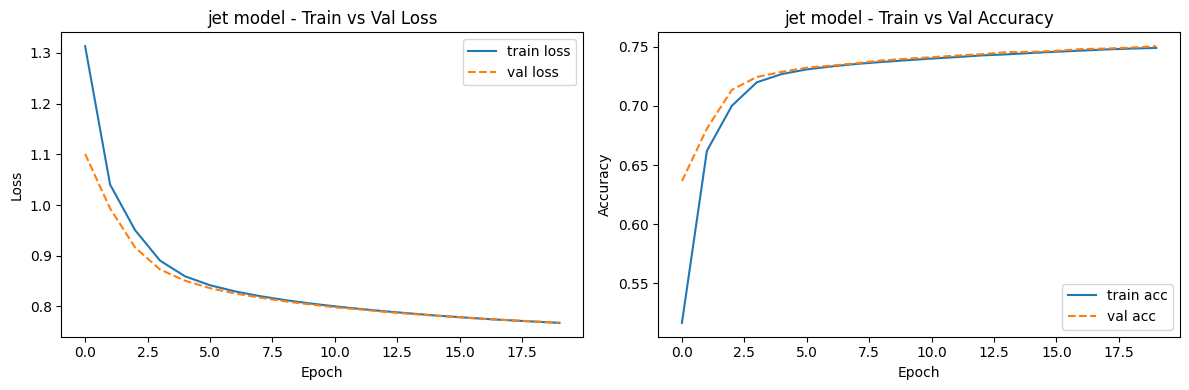

In [124]:
import matplotlib.pyplot as plt

def plot_history(history, name="model", title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)  # 1 row, 2 cols [web:270]

    # Loss
    axes[0].plot(history.history["loss"], label="train loss")
    axes[0].plot(history.history["val_loss"], "--", label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title_prefix}{name} - Train vs Val Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="train acc")
    axes[1].plot(history.history["val_accuracy"], "--", label="val acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title_prefix}{name} - Train vs Val Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history, name="jet model")


## 7. Feature Importance

We can again examine how strongly each input feature contributes to the model’s predictions. For a multi-class problem, this means looking at how features influence each class separately.

In this tutorial, we skip that analysis for now. Multi-class SHAP explanations are more involved than in the binary case, and highly correlated input features can also make feature importance harder to interpret reliably.

If you would still like to explore the SHAP values, set the `feature_importance` flag to `True`.

In [125]:
feature_importance = False

if feature_importance:
    import shap

    # Keep only a small subset for speed
    background_size = 100
    test_size = 300

    rng = np.random.default_rng(RANDOM_STATE)

    background_idx = rng.choice(len(X_train), size=background_size, replace=False)
    test_idx = rng.choice(len(X_test), size=test_size, replace=False)

    X_background = X_train[background_idx]
    X_explain = X_test[test_idx]

    X_explain_df = pd.DataFrame(X_explain, columns=feature_names)

    explainer = shap.DeepExplainer(model, X_background)
    shap_values = explainer.shap_values(X_explain)

    # For multiclass models, shap_values is often a list with one array per class
    for i, class_name in enumerate(class_names):
        shap.summary_plot(shap_values[:, :, i], X_explain_df, max_display=15, show=True)

## 8. Prediction Distributions

For each event, the model predicts a probability for all five jet classes rather than a single binary score. This lets us inspect how confidently the network assigns events to each class.
​

By plotting these probability distributions for each class, we can see how well the model separates the jet categories. Less overlap between the true-class scores and the other scores indicates better class separation.

3891/3891 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


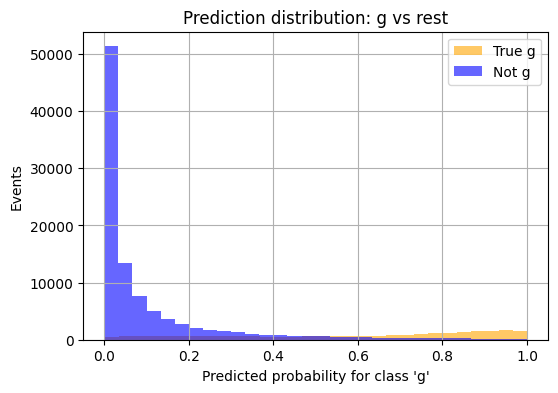

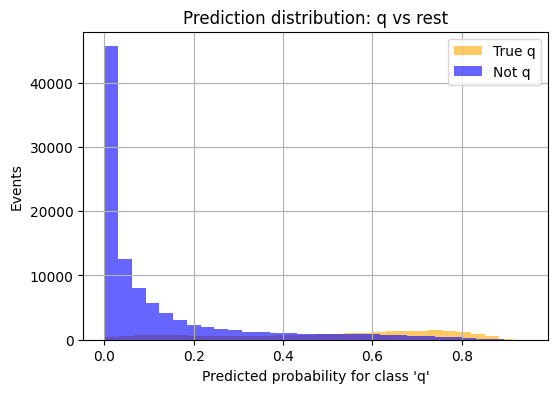

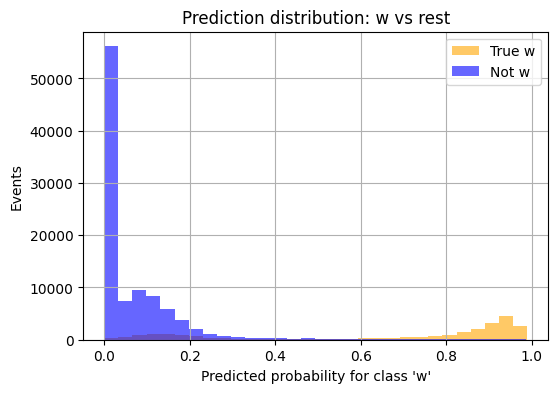

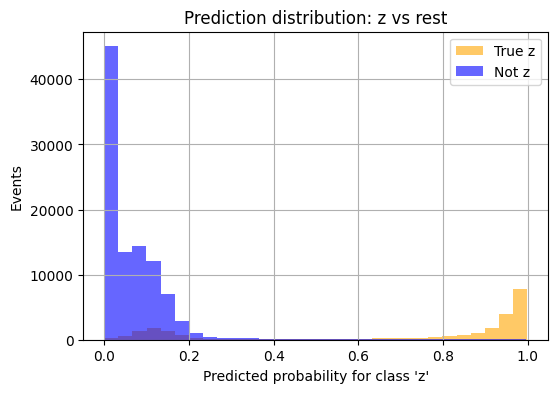

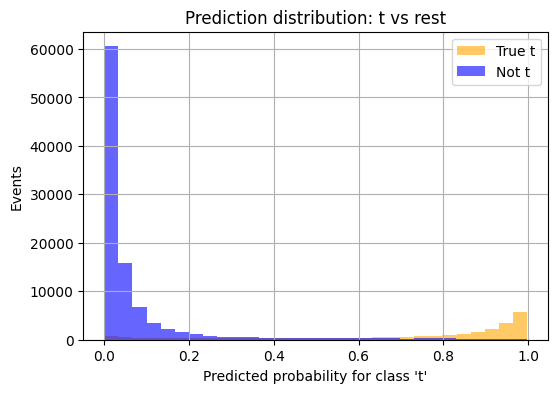

In [126]:
def plot_pred_distribution_multiclass(y_true, y_score, class_names, bins=30):
    for i, class_name in enumerate(class_names):
        plt.figure(figsize=(6, 4))
        plt.hist(y_score[y_true[:, i] == 1, i], bins=bins, alpha=0.6, label=f"True {class_name}", color="orange")
        plt.hist(y_score[y_true[:, i] == 0, i], bins=bins, alpha=0.6, label=f"Not {class_name}", color="blue")
        plt.xlabel(f"Predicted probability for class '{class_name}'")
        plt.ylabel("Events")
        plt.title(f"Prediction distribution: {class_name} vs rest")
        plt.legend()
        plt.grid(True)
        plt.show()

# Predict class probabilities
y_score = model.predict(X_test)
plot_pred_distribution_multiclass(y_test, y_score, class_names)

## 9. ROC Curve Comparison

We again use ROC curves to evaluate the model, now for the multi-class jet classification task. We plot one ROC curve for each jet class against the remaining classes, which shows how well the network separates each class individually.

In addition, we include the micro-average ROC curve. This combines the predictions from all classes into one overall ROC calculation, so it gives a single summary of performance across all class decisions rather than treating each class separately.

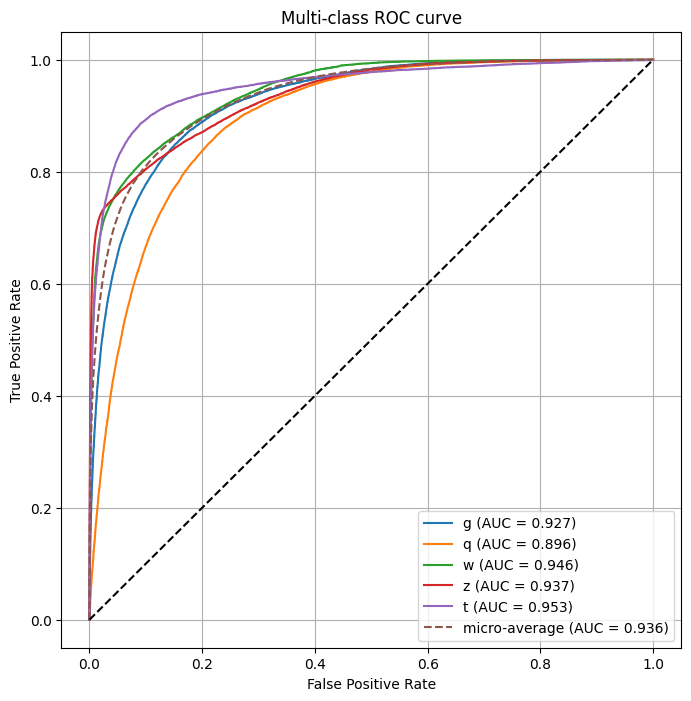

In [127]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Per-class ROC curves
plt.figure(figsize=(8, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", label=f"micro-average (AUC = {roc_auc_micro:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC curve")
plt.legend()
plt.grid(True)
plt.show()

There is also an alternative ROC representation commonly used in jet tagging and high-energy physics. It plots signal efficiency against background efficiency, so better performance appears toward the bottom right, where more signal is kept and less background is accepted. The percentages in the legend are the AUC values, which summarize how well each class is separated from the others. The logarithmic y-axis makes it easier to compare models in the low-background region, which is often the most relevant regime for physics analyses.

3891/3891 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Accuracy: 0.7476626506024097


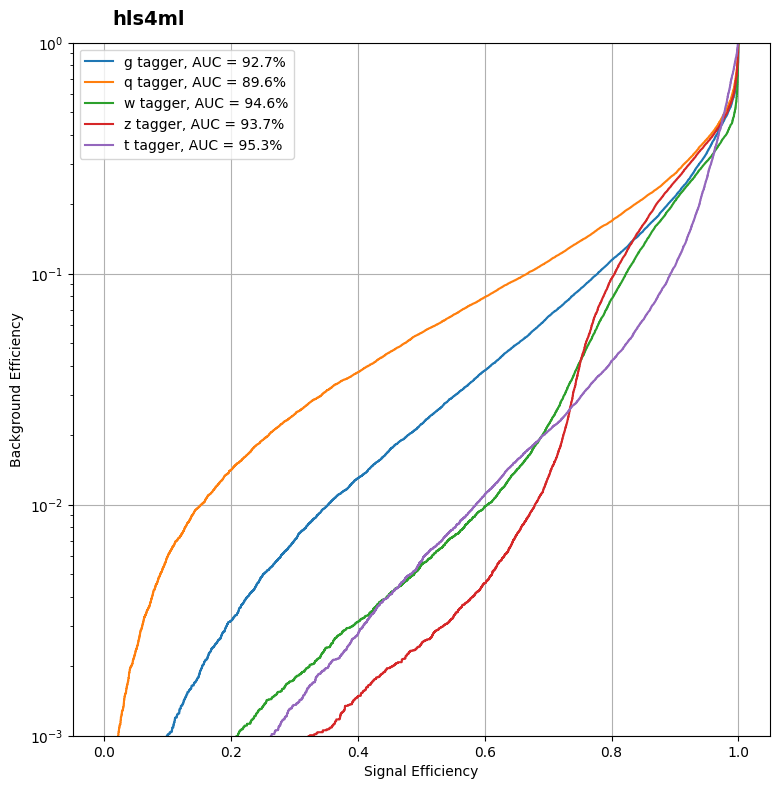

In [128]:
import plotting
from sklearn.metrics import accuracy_score

y_keras = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, class_names)

In [129]:
# @title
import ipywidgets as widgets
from IPython.display import display, Markdown
import re


display(Markdown("### Question 6"))
display(Markdown("Based on the ROC curves, how would you rank the jet classes from easiest to hardest for the model to distinguish?"))


answer = widgets.Textarea(
    placeholder="Write your answer here...",
    layout=widgets.Layout(width="700px", height="140px")
)


button = widgets.Button(description="Check answer", button_style="info")
output = widgets.Output()


def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def find_position(text, patterns):
    positions = []
    for p in patterns:
        match = re.search(rf"\b{re.escape(p)}\b", text)
        if match:
            positions.append(match.start())
    return min(positions) if positions else -1


def check_answer(b):
    user = normalize_text(answer.value)

    t_pos = find_position(user, ["t", "top", "top quark"])
    w_pos = find_position(user, ["w", "w boson"])
    z_pos = find_position(user, ["z", "z boson"])
    g_pos = find_position(user, ["g", "gluon"])
    q_pos = find_position(user, ["q", "qcd", "qcd jet"])

    has_t = t_pos != -1
    has_w = w_pos != -1
    has_z = z_pos != -1
    has_g = g_pos != -1
    has_q = q_pos != -1

    wz_group_ok = (
        "w/z" in user or "z/w" in user or "w and z" in user or "z and w" in user
        or (has_w and has_z)
    )

    middle_pos = min([p for p in [w_pos, z_pos] if p != -1], default=-1)

    order_ok = False
    if has_t and wz_group_ok and has_g and has_q and middle_pos != -1:
        order_ok = t_pos < middle_pos < g_pos < q_pos

    with output:
        output.clear_output()
        if order_ok:
            print("Correct!")
            print("The model distinguishes top jets best,")
            print("followed by W and Z jets, then gluon jets,")
            print("while QCD jets are the hardest to separate.")
        else:
            print("Not quite yet.")

            if not (has_t or has_w or has_z or has_g or has_q):
                print("- Hint: Rank the jet classes from easiest to hardest using either the class letters or the particle names.")

            elif not has_t:
                print("- Hint: Which jet type appears easiest to separate from the others?")

            elif not wz_group_ok:
                print("- Hint: Two electroweak boson classes perform similarly and belong together in the middle.")

            elif not has_g or not has_q:
                print("- Hint: Include the remaining jet types after the best and middle classes.")

            else:
                print("- Hint: Start with the easiest class, then the middle pair, then the last two in order.")


button.on_click(check_answer)


display(answer, button, output)

### Question 6

Based on the ROC curves, how would you rank the jet classes from easiest to hardest for the model to distinguish?

Textarea(value='', layout=Layout(height='140px', width='700px'), placeholder='Write your answer here...')

Button(button_style='info', description='Check answer', style=ButtonStyle())

Output()